In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.tools import diff
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

In [41]:
plt.rcParams["figure.figsize"] = [16, 5] 
# plt.rcParams['figure.dpi'] = 300         ## 300 for printing
plt.rc('font', size=8)                    
plt.rc('axes', titlesize=16)              
plt.rc('axes', labelsize=14)             
plt.rc('xtick', labelsize=10)            
plt.rc('ytick', labelsize=10)            
plt.rc('legend', fontsize=10)            
plt.rc('figure', titlesize=12)            

In this area, we shall be covering the following recipes:

* Forecasting time series data using auto_arima
* Forecasting time series data using Facebook prophet
* Forecasting time series data using VAR
* Evaluating vector autoregressive (VAR) models
* Forecasting volatility in financial time series data with GARCH

### 1. Forecasting time series data using auto_arima

Instead od training multiple models naively through grid-search to cover every possible combination of parameter values, ***auto_arima*** automates the process for finding the optimal parameters. The ***auto_arima*** uses ***stepwise*** algorithm that is more efficient and faster than a full grid search or a random search.

Stepwise is an optimization technique that utilizes grid search more efficiently. This is accomplished using unit root tests and minimizing information criteria (for example, **Akaike Information Criterion** (**AIC**) and **Maximum Likelihood Estimation** (**MLE**)).

Additionally, auto_arima can handle seasonal and non-seasonal ARIMA models. If seasonal ARIMA is desired, then you will need to set seasonal=True for auto_arima to optimize over the (P, D, Q) values.

In [2]:
import pmdarima as pm

In [3]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch11')

milk = pd.read_csv(path / 'milk_production.csv', index_col='month', parse_dates=True)

milk.head()

,production
month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(milk, test_size=.10, shuffle=False)

# same results using pmdarima
train, test = pm.model_selection.train_test_split(milk, test_size=.10)

print(f'Train: {train.shape}')
print(f'Test: {test.shape}')

Train: (151, 1)
Test: (17, 1)


You will use the auto_arima function from pmdarima to optimize and find the best configuration for your SARIMA model. Prior knowledge about the milk data is key to obtaining the best results from auto_arima. You know the data has a seasonal pattern, so you will need to provide values for the two parameters: seasonal=True and m=12 (the number of periods in a season). If these values are not set, the model will only search for the non-seasonal orders (p, d, q).

In [5]:
auto_model = pm.auto_arima(train, seasonal=True, m=12, test='adf', stepwise=True)

auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -475.008
Date:                            Thu, 23 Jan 2025   AIC                            956.016
Time:                                    11:55:27   BIC                            964.798
Sample:                                01-01-1962   HQIC                           959.585
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2714      0.082     -3.326      0.001      -0.431      -0.111
ma.S.L12      -0.6233      0.079     -7.908      0.000      -0.778      -0.469
sigma2        54.7638      5.498      9.960      0.000      43.987      65.540
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                31.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                             0.74
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Interestingly, the best model is a SARIMA(0,1,1)(0,1,1,12), is the same model you obtained in the Forecasting univariate time series data with non-seasonal ARIMA recipe in the previous chapter. You estimated the non-seasonal order (p, q) and seasonal orders (P, Q) using the ACF and PACF plots.

-------

To observe the score of the trained model at each iteration, you can use trace=True:

In [6]:
auto_model = pm.auto_arima(train, seasonal=True, m=12, test='adf', stepwise=True, trace=True)

auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=961.878, Time=2.97 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1005.341, Time=0.11 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=971.814, Time=0.62 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=956.016, Time=0.90 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=996.508, Time=0.15 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=957.982, Time=1.32 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=957.967, Time=2.75 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=971.938, Time=0.40 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=960.016, Time=1.43 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=964.474, Time=0.81 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=957.884, Time=0.64 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=957.783, Time=2.12 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=956.436, Time=0.66 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=959.701, Time=1.10 sec
 ARIMA(0,1,1)(0,1,1)[12] interce

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -475.008
Date:                            Thu, 23 Jan 2025   AIC                            956.016
Time:                                    11:55:44   BIC                            964.798
Sample:                                01-01-1962   HQIC                           959.585
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2714      0.082     -3.326      0.001      -0.431      -0.111
ma.S.L12      -0.6233      0.079     -7.908      0.000      -0.778      -0.469
sigma2        54.7638      5.498      9.960      0.000      43.987      65.540
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                31.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                             0.74
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
auto_model = pm.auto_arima(train, seasonal=True, m=12, test='adf', 
                           information_criterion='bic', stepwise=True,
                           trace=True)

auto_model.summary()

Performing stepwise search to minimize bic
 ARIMA(2,1,2)(1,1,1)[12]             : BIC=982.369, Time=3.42 sec
 ARIMA(0,1,0)(0,1,0)[12]             : BIC=1008.269, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : BIC=980.596, Time=0.74 sec
 ARIMA(0,1,1)(0,1,1)[12]             : BIC=964.798, Time=0.44 sec
 ARIMA(0,1,1)(0,1,0)[12]             : BIC=1002.362, Time=0.12 sec
 ARIMA(0,1,1)(1,1,1)[12]             : BIC=969.691, Time=0.70 sec
 ARIMA(0,1,1)(0,1,2)[12]             : BIC=969.676, Time=1.25 sec
 ARIMA(0,1,1)(1,1,0)[12]             : BIC=980.720, Time=0.67 sec
 ARIMA(0,1,1)(1,1,2)[12]             : BIC=974.652, Time=3.23 sec
 ARIMA(0,1,0)(0,1,1)[12]             : BIC=970.329, Time=0.28 sec
 ARIMA(1,1,1)(0,1,1)[12]             : BIC=969.593, Time=0.57 sec
 ARIMA(0,1,2)(0,1,1)[12]             : BIC=969.493, Time=1.59 sec
 ARIMA(1,1,0)(0,1,1)[12]             : BIC=965.218, Time=1.51 sec
 ARIMA(1,1,2)(0,1,1)[12]             : BIC=974.337, Time=1.96 sec
 ARIMA(0,1,1)(0,1,1)[12] interc

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -475.008
Date:                            Thu, 23 Jan 2025   AIC                            956.016
Time:                                    11:56:02   BIC                            964.798
Sample:                                01-01-1962   HQIC                           959.585
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2714      0.082     -3.326      0.001      -0.431      -0.111
ma.S.L12      -0.6233      0.079     -7.908      0.000      -0.778      -0.469
sigma2        54.7638      5.498      9.960      0.000      43.987      65.540
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                31.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                             0.74
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
auto_model.plot_diagnostics()

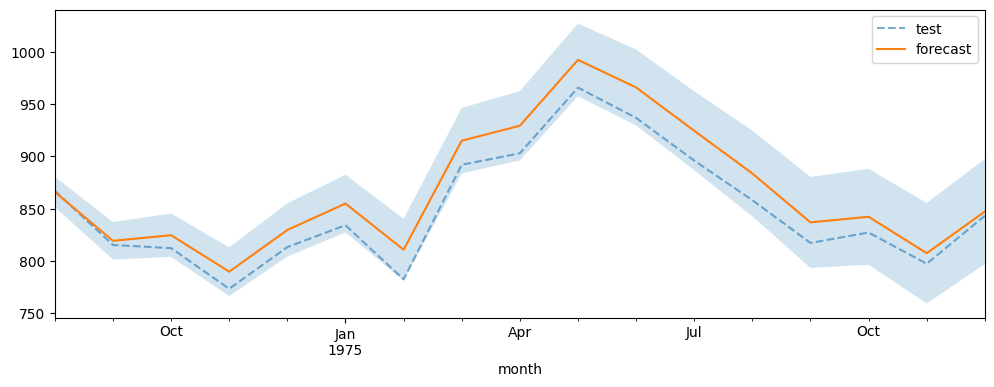

In [8]:
n = test.shape[0]
forecast, conf_interval = auto_model.predict(n_periods=n, return_conf_int=True)
lower_ci, upper_ci = zip(*conf_interval)

index = test.index
ax = test.plot(style='--', alpha=0.6, figsize=(12,4))
pd.Series(forecast, index=index).plot(style='-', ax=ax)
plt.fill_between(index, lower_ci, upper_ci, alpha=0.2)
plt.legend(['test','forecast']); plt.show()

The default confidence interval is set to 95% and can be controlled using the alpha parameter (alpha=0.05, which is 95% confidence interval) from the predict() method. The shaded area represents the likelihood that the real values would lie between this range. 

Ideally, you would prefer a narrower confidence interval range. Notice that the forecast line lies in the middle of the shaded area. This represents the mean of the upper and lower bounds. The following code demonstrates this:

In [9]:
sum(forecast) == sum(conf_interval.mean(axis=1))

True

The auto_arima function from the pmdarima library is a wrapper for the statsmodels SARIMAX class. auto_arima intelligently attempts to automate the process of optimizing the training process to find the best model and parameters. There are three ways to do so:

• The naive brute-force grid search method (full search)

• Random grid search

• The stepwise search algorithm

This is controlled by the stepwise parameter, which defaults to ***True***.

---------

The ***pmdarima*** library offers a plethora of useful functions to help you make informed decisions so that you can understand the data you are working with.

For example, the ***ndiff*** function performs stationarity tests to determine the differencing order, d, to make the time series stationary. The tests include the **Augmented Dickey-Fuller** (adf) test, the **Kwiatkowski–Phillips–Schmidt–Shin** (kpss) test, and the **Phillips-Perron** (pp) test.

Similarly, the ***nsdiff*** function helps estimate the number of seasonal differencing orders (D ) that are needed. The implementation covers two tests – the **Osborn-Chui-Smith-Birchenhall** (ocsb) and **Canova-Hansen** (ch) tests:

In [10]:
from pmdarima.arima.utils import ndiffs, nsdiffs

n_adf = ndiffs(milk, test='adf')                         # adf test
# KPSS test (the default in auto_arima):
n_kpss = ndiffs(milk, test='kpss')                       # kpss test
n_pp = ndiffs(milk, test='pp')                           # pp test

n_ocsb = nsdiffs(milk, test='ch' , m=10, max_D=12,)      # ocsb test
n_ch = nsdiffs(milk, test='ocsb', m=10, max_D=12,)       # ch test

In [39]:
print(f'Augmented Dickey-Fuller test: {n_adf}')
print(f'Kwiatkowski–Phillips–Schmidt–Shin test: {n_kpss}')
print(f'Philips-Perron test: {n_pp}')
print(f'Osborn-Chui-Smith-Birchenhall test: {n_ocsb}')
print(f'Canova-Hansen test: {n_ch}')

Augmented Dickey-Fuller test: 0
Kwiatkowski–Phillips–Schmidt–Shin test: 1
Philips-Perron test: 0
Osborn-Chui-Smith-Birchenhall test: 0
Canova-Hansen test: 0


In [11]:
model = pm.auto_arima(
    train,
    seasonal=True,
    with_intercept=True,
    d=1,
    max_d=2,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    m=12,
    D=1,
    max_D=2,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    information_criterion='aic',
    stepwise=False,
    out_of_sample_siz=25,
    test = 'kpss',
    score='mape',
    trace=True
)

 ARIMA(0,1,0)(0,1,0)[12] intercept   : AIC=1007.319, Time=0.04 sec
 ARIMA(0,1,0)(0,1,1)[12] intercept   : AIC=966.470, Time=0.78 sec
 ARIMA(0,1,0)(0,1,2)[12] intercept   : AIC=968.422, Time=1.81 sec
 ARIMA(0,1,0)(1,1,0)[12] intercept   : AIC=983.036, Time=0.81 sec
 ARIMA(0,1,0)(1,1,1)[12] intercept   : AIC=968.438, Time=0.51 sec
 ARIMA(0,1,0)(1,1,2)[12] intercept   : AIC=970.470, Time=1.17 sec
 ARIMA(0,1,0)(2,1,0)[12] intercept   : AIC=973.451, Time=0.97 sec
 ARIMA(0,1,0)(2,1,1)[12] intercept   : AIC=968.640, Time=1.45 sec
 ARIMA(0,1,0)(2,1,2)[12] intercept   : AIC=inf, Time=8.08 sec
 ARIMA(0,1,1)(0,1,0)[12] intercept   : AIC=998.468, Time=0.17 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=958.000, Time=1.00 sec
 ARIMA(0,1,1)(0,1,2)[12] intercept   : AIC=959.947, Time=1.40 sec
 ARIMA(0,1,1)(1,1,0)[12] intercept   : AIC=973.934, Time=1.03 sec
 ARIMA(0,1,1)(1,1,1)[12] intercept   : AIC=959.963, Time=1.05 sec
 ARIMA(0,1,1)(1,1,2)[12] intercept   : AIC=962.000, Time=1.87 sec
 ARIMA(0,1,1)

In [12]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -472.969
Date:                            Thu, 23 Jan 2025   AIC                            957.937
Time:                                    11:59:10   BIC                            975.501
Sample:                                01-01-1962   HQIC                           965.075
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0460      0.621     -0.074      0.941      -1.263       1.171
ar.L1         -1.1997      0.092    -13.044      0.000      -1.380      -1.019
ar.L2         -0.3072      0.098     -3.137      0.002      -0.499      -0.115
ma.L1          0.9585      0.066     14.616      0.000       0.830       1.087
ma.S.L12      -0.6124      0.084     -7.289      0.000      -0.777      -0.448
sigma2        52.8038      5.479      9.637      0.000      42.065      63.543
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                41.88
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.28   Skew:                             0.82
Prob(H) (two-sided):                  0.41   Kurtosis:                         5.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

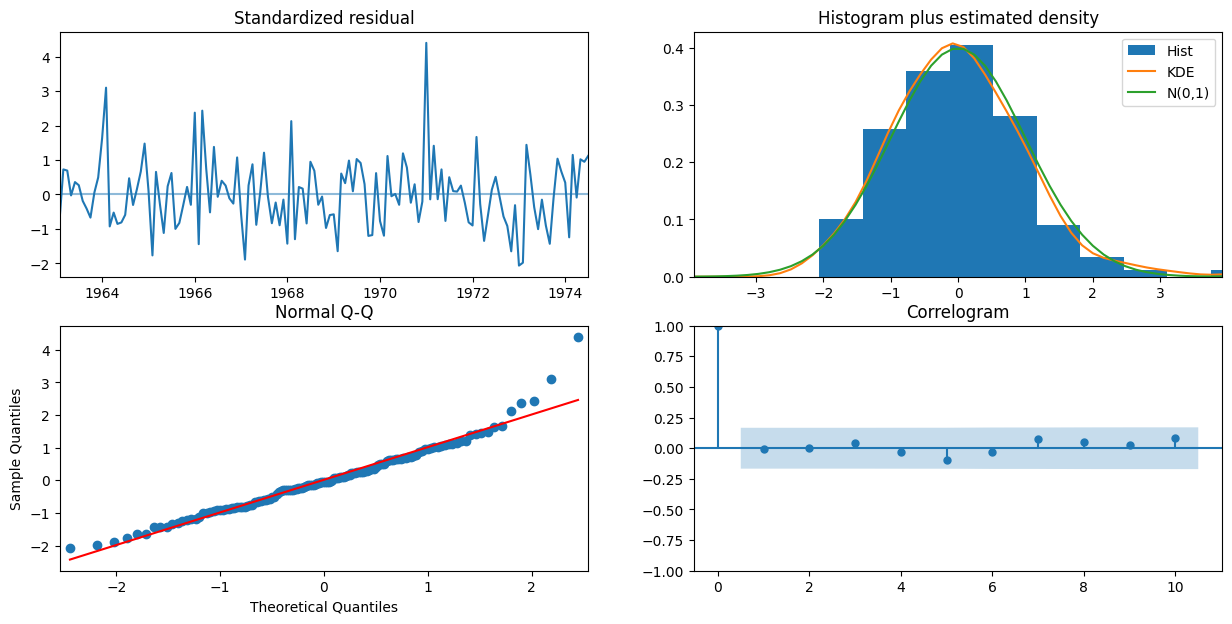

In [13]:
model.plot_diagnostics(figsize=(15,7)); plt.show()

In [14]:
model.out_of_sample_size

0

In [15]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -472.969
Date:                            Thu, 23 Jan 2025   AIC                            957.937
Time:                                    11:59:12   BIC                            975.501
Sample:                                01-01-1962   HQIC                           965.075
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0460      0.621     -0.074      0.941      -1.263       1.171
ar.L1         -1.1997      0.092    -13.044      0.000      -1.380      -1.019
ar.L2         -0.3072      0.098     -3.137      0.002      -0.499      -0.115
ma.L1          0.9585      0.066     14.616      0.000       0.830       1.087
ma.S.L12      -0.6124      0.084     -7.289      0.000      -0.777      -0.448
sigma2        52.8038      5.479      9.637      0.000      42.065      63.543
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                41.88
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.28   Skew:                             0.82
Prob(H) (two-sided):                  0.41   Kurtosis:                         5.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 2. Forecasting time series data using Facebook Prophet

The Prophet algorithm is an additive regression model that can handle non-linear trends
and works well with strong seasonal effects. The algorithm decomposes a time series into
three main components: trend, seasonality, and holidays. The model can be written
as follows:

            y(𝑡) = g(𝑡) + s(𝑡) + h(𝑡) + ϵ𝑡

Here, g(𝑡) is the trend function, s(𝑡) represents the periodic seasonality function, h(𝑡) covers effects of holidays, and ϵ𝑡 is the error term (residual).

The algorithm uses Bayesian inferencing to automate many aspects of tuning the model and finding the optimized values for each component. Behind the scenes, Prophet uses **Stan**, a library for Bayesian inferencing, through the **PyStan** library as the Python
interface to Stan.

In [16]:
from prophet import Prophet

milk = pd.read_csv(path / 'milk_production.csv', parse_dates=['month'])

milk.columns = ['ds','y']
milk.tail()

,ds,y
163,1975-08-01,858
164,1975-09-01,817
165,1975-10-01,827
166,1975-11-01,797
167,1975-12-01,843


In [17]:
# Split the data
idx = round(len(milk) * 0.90)
train = milk[:idx]
test = milk[idx:]

print(f'Train: {train.shape}')
print(f'Test: {test.shape}')

Train: (151, 2)
Test: (17, 2)


<Axes: title={'center': 'Monthly milk production'}, xlabel='ds'>

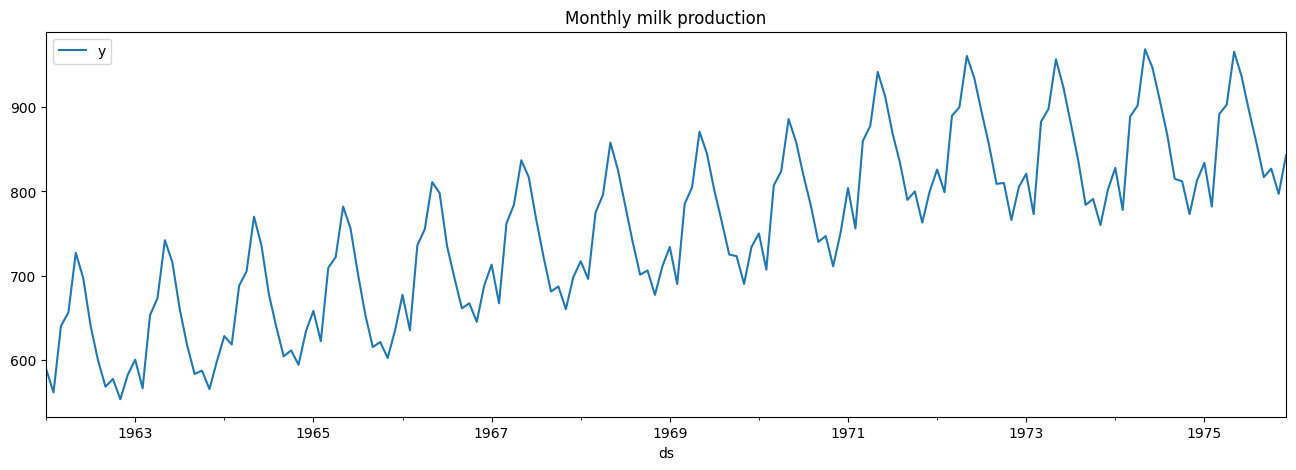

In [18]:
milk.set_index('ds').plot(title="Monthly milk production")

In [19]:
model = Prophet().fit(train)

11:59:14 - cmdstanpy - INFO - Chain [1] start processing
11:59:14 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
model.seasonalities

OrderedDict([('yearly',
              {'period': 365.25,
               'fourier_order': 10,
               'prior_scale': 10.0,
               'mode': 'additive',
               'condition_name': None})])

In [21]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

Some setup needs to be done before you can use the model to make predictions. Use the ***make_future_dataframe*** method to extend the train DataFrame forward for a specific number of periods and at a specified frequency:

In [22]:
future = model.make_future_dataframe(len(test), freq='MS')

In [23]:
future.tail()

,ds
163,1975-08-01
164,1975-09-01
165,1975-10-01
166,1975-11-01
167,1975-12-01


This extends the training data by 17 months (the number of periods in the test set). In total, you should have the exact number of periods that are in the milk DataFrame (train and test). The frequency is set to month start with freq='MS'. The future object only contains one column, ds, of the datetime64[ns] type, which is used to populate the predicted values:

In [24]:
len(milk) == len(future)

True

Now, use the predict method to take the future DataFrame and make predictions. The result will be a DataFrame that's the same length as forecast but now with additional columns:

In [25]:
forecast = model.predict(future)
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [26]:
cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']

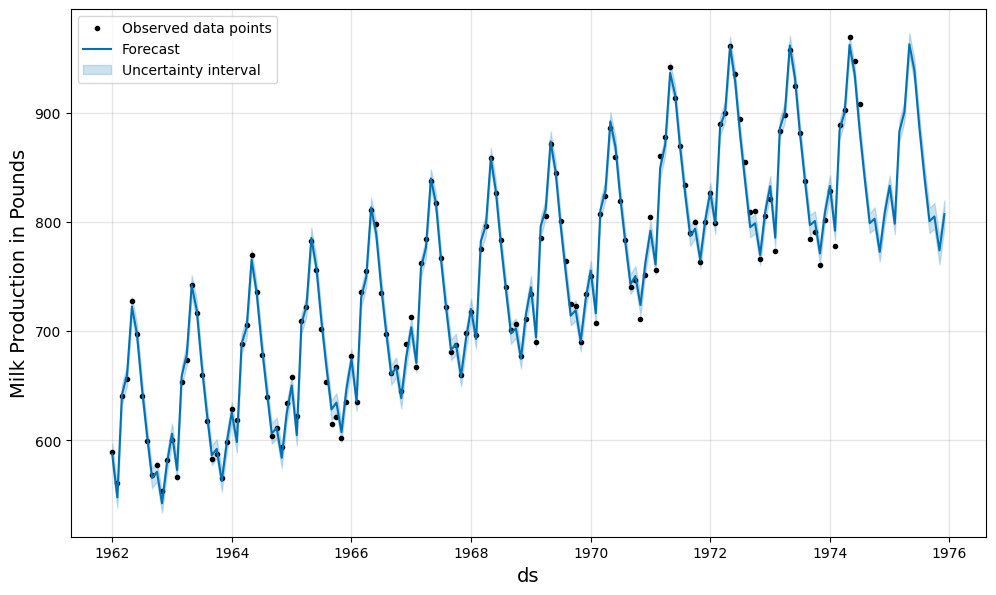

In [42]:
model.plot(forecast, ylabel='Milk Production in Pounds'); plt.legend(); plt.show()

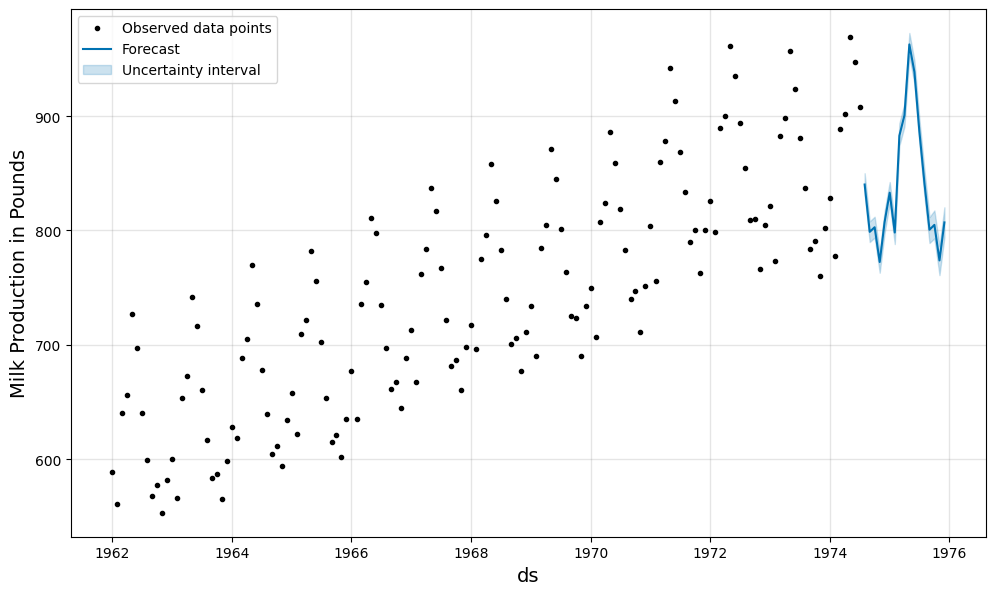

In [43]:
predicted = model.predict(test)
model.plot(predicted, ylabel='Milk Production in Pounds'); plt.legend(); plt.show()

In [29]:
predicted.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1974-08-01,854.317989,831.048450,849.778619,854.317989,854.317989,-14.168785,-14.168785,-14.168785,-14.168785,-14.168785,-14.168785,0.0,0.0,0.0,840.149204
1,1974-09-01,854.447146,789.450627,807.892364,854.313709,854.565187,-55.712688,-55.712688,-55.712688,-55.712688,-55.712688,-55.712688,0.0,0.0,0.0,798.734458
2,1974-10-01,854.572136,793.441080,812.266986,854.195052,854.926216,-51.800679,-51.800679,-51.800679,-51.800679,-51.800679,-51.800679,0.0,0.0,0.0,802.771457
3,1974-11-01,854.701292,762.895419,781.277479,854.005674,855.373954,-82.336627,-82.336627,-82.336627,-82.336627,-82.336627,-82.336627,0.0,0.0,0.0,772.364666
4,1974-12-01,854.826282,797.994441,816.885113,853.668456,855.842445,-47.347332,-47.347332,-47.347332,-47.347332,-47.347332,-47.347332,0.0,0.0,0.0,807.478950


In [30]:
predicted.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [45]:
predicted[cols].head()

,ds,yhat,yhat_lower,yhat_upper
0,1974-08-01,840.149204,831.234439,850.032635
1,1974-09-01,798.734458,789.775223,807.935642
2,1974-10-01,802.771457,793.758165,811.987877
3,1974-11-01,772.364666,762.958669,781.314648
4,1974-12-01,807.478950,797.998566,816.991526


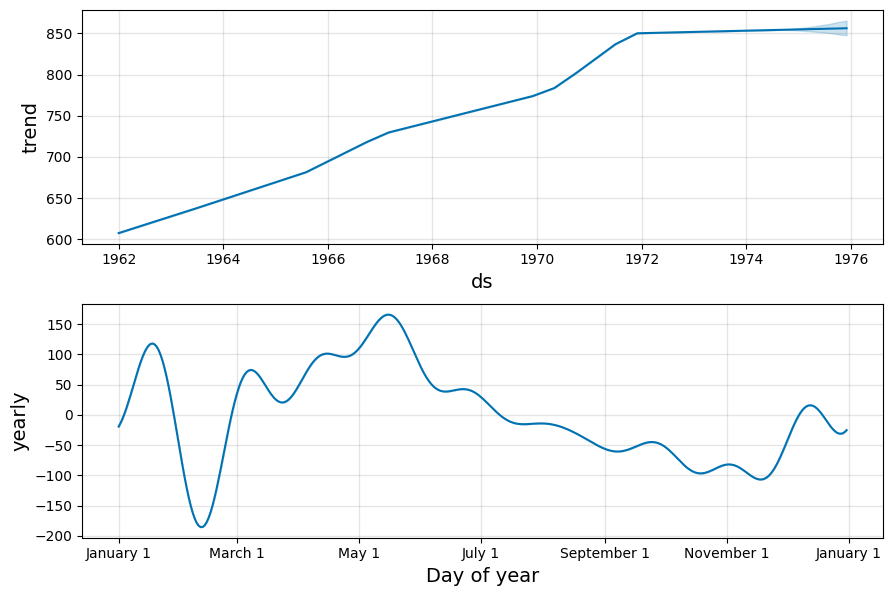

In [44]:
model.plot_components(forecast); plt.show()

The shaded area in the trend plot represents the uncertainty interval for estimatingthe trend. The data is stored in the trend_lower and trend_upper columns of the forecast DataFrame.

Finally, compare with out-of-sample data (the test data) to see how well the model performs:

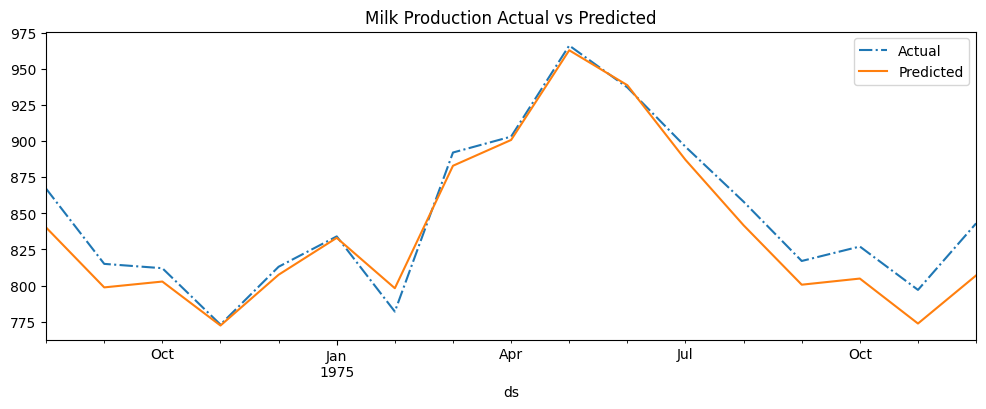

In [32]:
ax = test.plot(x='ds', y='y', label='Actual', style='-.', figsize=(12, 4))
predicted.plot(x='ds', y='yhat', label='Predicted', ax=ax)
plt.title('Milk Production Actual vs Predicted'); plt.show()

Notice that for the highly seasonal milk production data, the model did a great job. Generally, Prophet shines when it's working with strong seasonal time series data.

***yearly_seasonality***, ***weekly_seasonality***, and ***daily_seasonality*** are set to auto by default, this allows Prophet to determine which ones to turn on or off based on the data.

As per Prophet's documentation, there are three components for the uncertainty intervals
(for example, yhat_lower and yhat_upper):

• Observation noise

• Parameter uncertainty

• Future trend uncertainty

By default, the ***uncertainty_samples*** parameter is set to 1000, which is the number of simulations to estimate the uncertainty using the **Hamiltonian Monte Carlo** (**HMC**) algorithm. You can always reduce the number of samples that are simulated or set it to 0 or False to speed up the performance. If you set ***uncertainty_samples=0*** or ***uncertainty_samples=False***, the forecast's output will not contain any uncertainty interval calculations. For example, you will not have ***yhat_lower*** or ***yhat_upper***.

Prophet automatically detects changes or sudden fluctuations in the trend. Initially, it will place 25 points using the first 80% of the training data. You can change the number of changepoints with the ***n_changepoints*** parameter. Similarly, the proportion of past data to use to estimate the changepoints can be updated using ***changepoint_range***, which defaults to 0.8 (or 80%). You can observe the 25 changepoints using the changepoints attribute from the model object. The following code shows the first five:

In [33]:
changepoints = model.changepoints; changepoints.head()

5    1962-06-01
10   1962-11-01
14   1963-03-01
19   1963-08-01
24   1964-01-01
Name: ds, dtype: datetime64[ns]

This should produce a plot that contains the original time series data and the 25 potential
changepoints that indicate changes in trend:

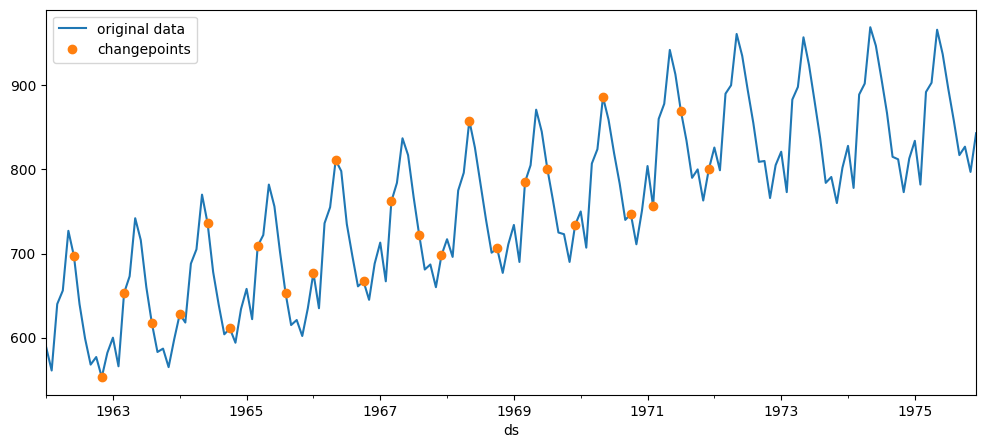

In [34]:
ax = milk.set_index('ds').plot(figsize=(12, 5))
milk.set_index('ds').loc[model.changepoints].plot(style='o', ax=ax)
plt.legend(['original data', 'changepoints']); plt.show()

These potential changepoints were estimated from the first 80% of the training data.

--------

To plot the significant changepoints that capture the impactful changes in trend, you can use the ***add_changepoints_to_plot*** function

In [35]:
from prophet.plot import add_changepoints_to_plot

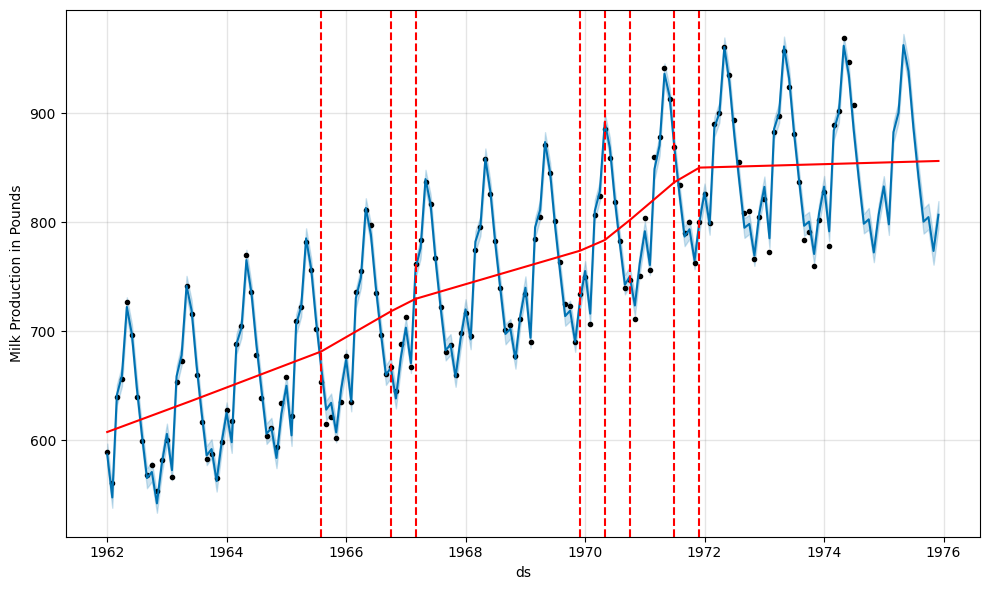

In [36]:
fig = model.plot(forecast, ylabel='Milk Production in Pounds')
add_changepoints_to_plot(fig.gca(), model, forecast); plt.show()

The plot above will be similar to its predecessor, but with the additional lines and the trend line. 8 significant changepoints are shown out of the 25. The linear trend line should be the same as the trend component.

### 3. Forecasting time series data using Vector Autoregressive (VAR)

There are other forms of multivariate time series models, including **Vector Moving Average** (**VMA**), **Vector Autoregressive Moving Average** (**VARMA**), and Vector **Autoregressive Integrated Moving Average** (**VARIMA**), that generalize other univariate models. In practice, you will find that VAR is used the most due to its simplicity. **VAR** models are very popular in economics, but you will find them being used in other areas, such as social sciences, natural sciences, and engineering.

The premise behind multivariate time series is that you can add more power to your forecast when leveraging multiple time series (or inputs variables) as opposed to a single time series (single variable). Simply put, VAR is used when you have two or more time series that have (or are assumed to have) an influence on each other's behavior. These are normally referred to as **endogenous** variables and the relationship is bi-directional. If the variables or time series are not directly related, or we do not know if there is a direct influence within the same system, we refer to them as **exogenous** variables.

A VAR model, like an AR model, assumes the stationarity of the time series variables. This means that each endogenous variable (time series) needs to be stationary. To illustrate how VAR works and the mathematical equation behind it, let's start with a simple VAR(1) with two endogenous variables, referred to as ( 𝑦𝑦1,𝑡𝑡 , 𝑦𝑦2,𝑡𝑡 ). Recall from Chapter 10, Building Univariate Time Series Models Using Statistical Methods, that an AR(1) model would take the following form:

            𝐴(1) = 𝑦𝑡 = α + θ1 𝑦𝑡−1 + ϵ𝑡

Generally, an AR(p) model is a linear model of past values of itself and the (p) parameter tells us how far back we should go. Now, assume you have two AR(1) models for two different time series data. This will look as follows:

            𝑦(1),𝑡 = α1 + θ11 𝑦(1),𝑡−1 + ϵ(1),𝑡
            𝑦(2),𝑡 = α2 + θ21 𝑦(2),𝑡−1 + ϵ(2),𝑡

However, these are two separate models that do not show any relationship or that influence each other. If we create a linear combination of the two models (the past values of itself and the past values of the other time series)

The preceding equation may seem complex, but in the end, like an AR model, it is still simply a linear function of past lags. In other words, in a VAR(1) model, you will have a linear function of lag 1 for each variable. When fitting a VAR model, as you shall see in this recipe, the **Ordinary Least Squares** (**OLS**) method is used for each equation to estimate the VAR model.

#### Exogenous versus Endogenous Variables

When you start researching more about VAR models, you will come across references to endogenous and exogenous variables. At a high level, the two are the opposite of each other and in statsmodels, you will see them referenced as endog and exog, respectively.

**Endogenous** variables are influenced by other variables within the system. In other words, we expect that a change in one's state affects the other. Sometimes, these can be referred to as dependent variables in machine learning literature. You can use the Granger causality tests to determine if there is such a relationship between multiple endogenous variables. For example, in statsmodels, you can use ***grangercausalitytests***.

On the other hand, **exogenous** variables are outside the system and do not have a direct influence on the variables. They are external influencers. Sometimes, these can be referred to as independent variables in machine learning literature.

In [46]:
import pandas_datareader.data as web
from statsmodels.tsa.api import VAR, adfuller, kpss
from statsmodels.tsa.stattools import grangercausalitytests

In [47]:
start = "01-01-1990"
end = "04-01-2022"
economic = web.FredReader(symbols=["FEDFUNDS", "unrate"], start=start, end=end).read()
file = '../../Datasets/economic.pickle'
economic.to_pickle(file)

ReadTimeout: HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Read timed out. (read timeout=30)

In [89]:
economic.isna().sum()

FEDFUNDS    0
unrate      0
dtype: int64

In [90]:
# Change the DataFrame's frequency to month start (MS) to reflect how the data is being stored:
economic.index.freq = 'MS'

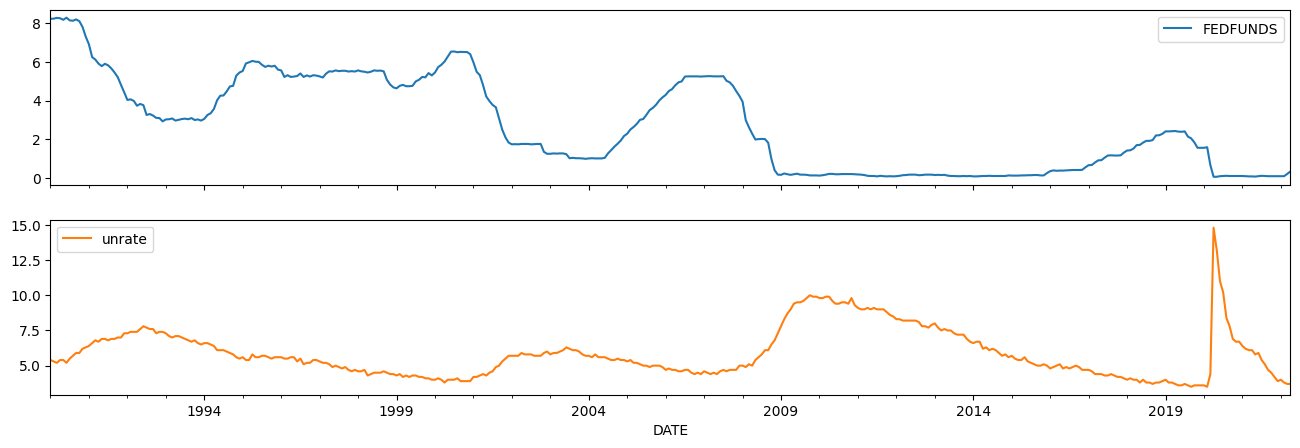

In [91]:
# Plot the datasets for visual inspection and understanding:
economic.plot(subplots=True); plt.show()

There is some sort of inverse relationship between FEDFUND and unrate – as FEDFUNDS increases, unrate decreases. There is interesting anomalous behavior starting in 2020 due to the COVID-19 pandemic.

------

An important assumption in VAR is stationarity. Both variables (the two endogenous time series) need to be stationary.

In [92]:
def check_stationarity(df):
    kps = kpss(df)
    adf = adfuller(df)
    kpss_pv, adf_pv = kps[1], adf[1]      # p-values of kpss and adf tests
    kpssh, adfh = 'Stationary', 'Non-stationary'

    if adf_pv < 0.05:
        # Reject ADF Null Hypothesis
        adfh = 'Stationary'
    if kpss_pv < 0.05:
        # Reject KPSS Null Hypothesis
        kpssh = 'Non-stationary'
        
    return (kpssh, adfh)

In [93]:
for i in economic:
    kps, adf = check_stationarity(economic[i])
    print(f'{i} adf: {adf}, kpss: {kpss}')

FEDFUNDS adf: Stationary, kpss: <function kpss at 0x75e345ed94e0>
unrate adf: Stationary, kpss: <function kpss at 0x75e345ed94e0>


Granger causality tests are implemented in statsmodels with the grangercausalitytests function, which performs four tests across each past lag. You can control this using the maxlag parameter. Granger causality tests are
used to determine if past values from one variable influence the other variable. In statsmodels, at each lag, it will show the tests that have been performed and their results: the test statistics score, the p-value, and the degrees of freedom. Let's focus on the p-value to decide if you should reject or accept the null hypothesis.

The null hypothesis in the Granger causality tests is that the second variable or column (that is, FEDFUNDS) does not Granger cause the first variable or column (that is, unrate). In other words, it assumes there is no statistical significance in terms of influence or effect. If you are trying to predict unrate and determine if
FEDFUNDS influences unrate, you will need to switch the order of the columns before applying the test. This is because grangercausalitytests examines the second column against the first column:

In [94]:
granger = grangercausalitytests(economic[['unrate','FEDFUNDS']], maxlag=12)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5913  , p=0.4424  , df_denom=384, df_num=1
ssr based chi2 test:   chi2=0.5959  , p=0.4402  , df=1
likelihood ratio test: chi2=0.5954  , p=0.4403  , df=1
parameter F test:         F=0.5913  , p=0.4424  , df_denom=384, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=21.7672 , p=0.0000  , df_denom=381, df_num=2
ssr based chi2 test:   chi2=44.1057 , p=0.0000  , df=2
likelihood ratio test: chi2=41.7628 , p=0.0000  , df=2
parameter F test:         F=21.7672 , p=0.0000  , df_denom=381, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=21.6011 , p=0.0000  , df_denom=378, df_num=3
ssr based chi2 test:   chi2=66.0033 , p=0.0000  , df=3
likelihood ratio test: chi2=60.9190 , p=0.0000  , df=3
parameter F test:         F=21.6011 , p=0.0000  , df_denom=378, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=16.1445 , p=0.0000  

Here, all the lags (except for lag 1) have a p-value less than 0.05, which indicates that we can reject the null hypothesis. This means that the effect of FEDFUNDS is statistically significant. We can say that FEDFUNDS does Granger cause unrate.

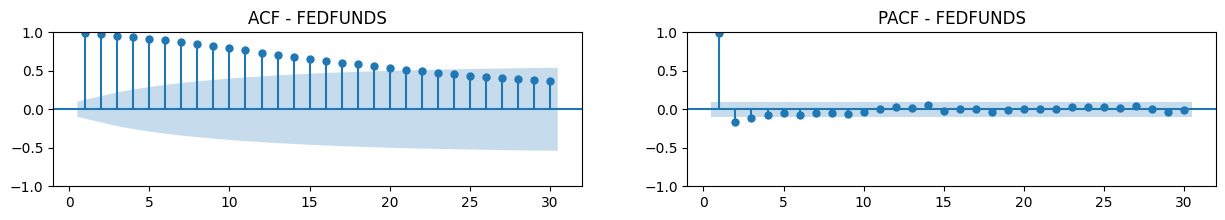

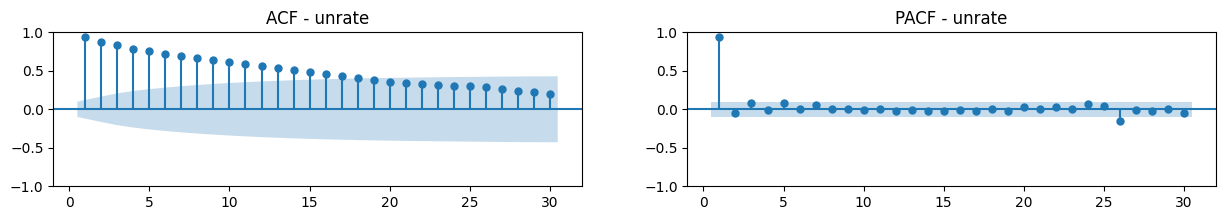

In [95]:
for col in economic.columns:
    fig, ax = plt.subplots(1,2)
    plot_acf(economic[col], zero=False, lags=30, ax=ax[0], title=f'ACF - {col}')
    plot_pacf(economic[col], zero=False, lags=30, ax=ax[1], title=f'PACF - {col}')
    plt.show()

Notice that for FEDFUNDS and unrate, the plots indicate we are dealing with an autoregressive (AR) process. The ACF is gradually decaying, while both PACF plots show a sharp cutoff after lag 1. The PACF for FEDFUNDS shows slightly significant (above or below the shaded area) lags at 2 and 3, while the PACF for unrate shows
some significance at lag 24.

-------

There is often a debate if the variables need to be scaled (standardized) or not when implementing VAR. Generally, when it comes to VAR, the algorithm does not require the variables to be scaled (some algorithms, on the other hand, will require the data to be scaled). Since you will be working with multivariate time series (multiple variables) that may have different scales, it would be easier to interpret the residuals from each if the data is scaled. Similarly, the coefficients will become easier to compare since the units will be in standard deviation (for more insight, please refer to the Detecting outliers using Z-score recipe in previous recipe, Outlier Detection Using Statistical Methods). In this step, you will perform scaling as a best practice. You will use the StandardScalar class from Scikit-Learn since it will provide you with the inverse_transform method so that you can return to the original scale. In the future recipes, Deep Learning for Time Series Forecasting, in the Preparing time series data for deep learning recipe, you will implement a class to scale and inverse transform.

In [96]:
train = economic.loc[:'2019']
test = economic.loc['2020':]
print(f'Train: {len(train)}, Test: {len(test)}')

Train: 360, Test: 28


In [97]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
scale.fit(train)

train_sc = pd.DataFrame(scale.transform(train), index=train.index, columns=train.columns)
test_sc = pd.DataFrame(scale.transform(test), index=test.index, columns=test.columns)

But how can you pick the VAR order P? Luckily, the VAR implementation in statsmodels will pick the best VAR order. You only need to define the maximum number of lags (threshold); the model will determine the best p values that
minimize each of the four information criteria scores: AIC, BIC, FPE, and HQIC. The select_order method will compute the scores at each lag order, while the summary method will display the scores for each lag. The results will help when you train (fit) the model to specify which information criteria the algorithm should use:

In [98]:
model = VAR(endog=train_sc, freq='MS')
res = model.select_order(maxlags=10)
res.summary()

,AIC,BIC,FPE,HQIC
0,-0.3447,-0.3227,0.7084,-0.3360
1,-9.991,-9.925,4.579e-05,-9.965
2,-10.52,-10.41,2.711e-05,-10.47
3,-10.56,-10.41,2.590e-05,-10.50
4,-10.61,-10.41*,2.468e-05,-10.53*
5,-10.61,-10.36,2.475e-05,-10.51
6,-10.62,-10.34,2.431e-05,-10.51
7,-10.66*,-10.32,2.358e-05*,-10.52
8,-10.64,-10.26,2.402e-05,-10.49
9,-10.63,-10.21,2.429e-05,-10.46


In [99]:
res.selected_orders

{'aic': 7, 'bic': 4, 'hqic': 4, 'fpe': 7}

In [100]:
results = model.fit(maxlags=7, ic='aic')

In [101]:
results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 23, Jan, 2025
Time:                     11:03:51
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -10.3234
Nobs:                     353.000    HQIC:                  -10.5212
Log likelihood:           908.302    FPE:                2.36566e-05
AIC:                     -10.6520    Det(Omega_mle):     2.17674e-05
--------------------------------------------------------------------
Results for equation FEDFUNDS
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -0.002751         0.002960           -0.929           0.353
L1.FEDFUNDS         1.438116         0.053641           26.810           0.000
L1.unrate          -0.073048         0.033805           -2.161   

Toward the end of the summary, the correlation matrix for the residuals is displayed. It provides insight into whether all the information was captured by the model or not. The following output does not show a correlation. Ideally, we want it to be as close to zero as possible.

------ 

Store the VAR lag order using the k_ar attribute so that we can use it later when we use the forecast method:

In [ ]:
lag_order = results.k_ar
lag_order

Finally, you can forecast using either the forecast or forecast_interval method. The latter will return the forecast, as well as the upper and lower confidence intervals. Both methods will require past values and the number
of steps ahead. The prior values will be used as the initial values for the forecast:

In [ ]:
past_y = train_sc[-lag_order:].values
n = test_sc.shape[0]
forecast, lower_bound, upper_bound = results.forecast_interval(past_y, steps=n)

In [ ]:
# Plot the forecast with the confidence intervals
forecast, lower, upper = results.forecast_interval(past_y, steps=n)
idx = test.index; style = 'k--'

ax = train_sc.iloc[:-lag_order, 1].plot(style='k')
pred_forecast = pd.Series(forecast[:, 1], index=idx).plot(ax=ax, style=style)
pred_lower = pd.Series(lower[:, 1], index=idx).plot(ax=ax, style=style)
pred_upper = pd.Series(upper[:, 1], index=idx).plot(ax=ax, style=style)
plt.fill_between(idx, lower[:,1], upper[:,1], alpha=0.12)
plt.title('Forecasting Unemployment Rate (unrate)')
plt.legend(['Train','Forecast']); plt.show()

------ 

Since we are focusing on comparing the forecasting results, it would be interesting to see if our VAR(7) model, with two endogenous variables, is better than a univariate AR(7) model. Try using an AR(7) or ARIMA(7,0,0) model; you will use the same lag values for consistency. Recall that the unrate time series was stationary, so there is no need for differencing:

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train_sc['unrate'],
order=(lag_order,0,0)).fit()

In [ ]:
fig = model.plot_diagnostics()
fig.tight_layout(); plt.show()

In [48]:
from statsmodels.tools.eval_measures import mse

In [ ]:
np.sqrt(mse(test['unrate'], forecast[:, 1]))

In [ ]:
np.sqrt(mse(test['unrate'], model.forecast(n)))

### 5. Evaluating vector autoregressive (VAR) models

An important step when building a VAR model is to understand the model in terms of the interactions between the different endogenous variables. The statsmodels VAR implementation provides key plots to help you analyze the complex dynamic relationship between these endogenous variables (multiple time series). In this recipe, you will continue where you left off from the previous recipe, ***Forecasting multivariate time series data using VAR***, and explore different diagnostic plots, such as the **Residual Autocorrelation Function** (**ACF**), **Impulse Response Function** (**IRF**), and **Forecast Error Variance Decomposition** (**FEVD**).

In [ ]:
results.plot_acorr(); plt.show()

In [ ]:
results.plot_acorr(resid=True)

The first row of plots is based on the first variable in the DataFrame (FEDFUNDS), while the second row is based on the second variable in the DataFrame (unrate). Recall that for two variables, you will have two functions or models, and this translates into 2x2 residual subplots, as shown in Figure 11.16. If you had three variables, you would have a 3x3 subplot.

You do not want the residuals to show any significance across the lags, which is the case in the plot above. This indicates that the model captured all the necessary information. In other words, there are no signs of any autocorrelation, which is what we would hope for.

In [ ]:
for col in results.resid.columns:
    fig, ax = plt.subplots(1,1, figsize=(10,2))
    plot_acf(results.resid[col], zero=False, lags=10, ax=ax, title=f'ACF - {col}')

In [ ]:
# Analyze the impulse response to shocks in the system using the irf method
irf = results.irf()
irf.plot(); plt.show()

The IRF analysis computes the dynamic impulse responses and the approximated standard errors, and also displays the relevant plots. The idea here is that in VAR, all the variables influence each other, and the impulse response (IR) traces the effect of a change (impulse) in one variable and the response from another variable (for each variable available) over each lag. The default is the first 10 lags. This technique is used to understand the dynamics of the relationship.

E.g, the plot that shows FEDFUNDS → unrate in Figure 11.17 illustrates how unrate responds to a one-point increase in FEDFUNDS across the 10 lags. More specifically, at lag 1, as FEDFUNDS increases, a negative reaction in unrate
occurs (lower unemployment). Then, between periods 1 and 2, it looks like it is steady while FEDFUNDS increases, indicating a delayed shock or reaction (response), which is expected. A similar reaction is seen in period 3 in which a negative reaction (drop) in unrate is seen but then a short delay between periods 3 and 4, which drops further in period 5, can also be seen. In other words, increasing the federal funds effective rate (FEDFUNDS) did lower the unemployment rate, but the response is slower in the early periods before the full effect is shown.

If you do not want to see all four subplots, you can specify which plot you want to see by providing an impulse variable and a response variable:

In [ ]:
fig = irf.plot(impulse='FEDFUNDS', response='unrate',
figsize=(5, 5))

In [ ]:
# Plot the cumulative response effect
irf.plot_cum_effects(); plt.show()

In [ ]:
# You can get the FEVD using the fevd method
fv = results.fevd()

# You can use two methods here: fv.summay() and fv.plot(). Both provide similar information
fv.plot(); plt.show()

This will produce two FEVD plots – one for each variable. The x-axis will show the number of periods (0 to 9), while the y-axis will represent the percent (0 to 100%) that each shock contributed. Visually, this is represented as a portion of the total bar at every period. This contribution is the error variance:

In [ ]:
results.plot_forecast(n, plot_stderr=True)

### 5. Forecasting volatility in financial time series data with GARCH

When working with financial time series data, the key task is measuring **volatility** to represent uncertainty in future returns. Volatility measures the spread of the probability distribution of returns and is calculated as the variance (or standard deviation) and used as proxy for quantifying volatility or risk. In other term, it measures the dispersion of financial asset returns around the expected value. A high volatility shows higher risks, thus helping investors, e.g, understand the level of return they can expect to get and how often their returns differ from an expected value of the return.

Most of the models we discussed previously (for example, ARIMA, SARIMA, and Prophet) focused on forecasting an observed variable based on past versions of itself. These models lack modeling changes in variance over time (heteroskedasticity).

In this recipe, you will work with a different kind of forecasting: forecasting and modeling changes in variance over time. This is known as volatility. In general, volatility is an important measure of risk when there is uncertainty and it is an important concept when working with financial data.

**Autoregressive Conditional Heteroskedasticity** (**ARCH**). The ARCH algorithm modelsthe change in variance over time as a function of squared error terms (innovations) of a time series. An extension of ARCH is the **GARCH** model, which stands for **Generalized Autoregressive Conditional Heteroskedasticity**. It extends ARCH by adding a moving average component.

GARCH is popular in econometrics and is used by financial institutes that assess investments and financial markets. Predicting turbulence and volatility is as important as trying to predict a future price, and several trading strategies utilize volatility, such as the mean reversion strategy.

Before moving on, let's define the components of a general ARCH model:
* ***Autoregressive***, a concept we explored in Chapter 10, Building Univariate Time Series Models Using Statistical Methods, means that the current value of a variable is influenced by past values of itself at different periods.
* ***Heteroskedasticity*** means that the model may have different magnitudes or variability at different time points (variance changes over time).
• ***Conditional***, since volatility is not fixed, the reference here is on the constant that we place in the model to limit heteroskedasticity and make it conditionally dependent on the previous value or values of the variable.

In this recipe, you will create a GARCH model of order (p, q), also known as lags. q is the number of past (lag) squared residual errors ϵ2, while q is the number of past (lag) variances σ2 since variance is the square of standard deviation.

-----------

**GARCH Orders**

It can sometimes be confusing when talking about the p and q orders. In literature, q is usually the ARCH order, while p is the GARCH order, as described earlier. In the arch Python library, they are switched. In the arch
package, p is described as the lag order of the symmetric innovation, while q is described as the lag order of lagged volatility.

-------


'''
From arch , you will use the arch_model function. The parameters can be broken down into three main components based on the GARCH model's assumptions: a distribution that's controlled by the dist parameter that defaults to normal, a mean model that's controlled by the mean parameter that defaults to Constant, and a volatility process that's controlled by the vol parameter that defaults to GARCH.
'''

In [49]:
from arch import arch_model

In [51]:
msft_df = pd.read_csv(path / "msft.csv", index_col='Date', parse_dates=True)
msft_df.head()

,close
Date,
2010-01-04,23.904985
2010-01-05,23.912710
2010-01-06,23.765955
2010-01-07,23.518789
2010-01-08,23.680998


You will need to convert the daily stock price into a daily stock return. This can be calculated as  

            𝑅 = (𝑃𝑡 − 𝑃𝑡−1)/(𝑃𝑡−1)
            whereas: 𝑃𝑡 is the price at time 𝑡𝑡 and 𝑃𝑡−1 is the previous price (1 day prior). 
            
This can easily be done in pandas using the DataFrame.pct_
change() function..pct_change() has a periods parameter that defaults to

1. If you want to calculate a 30-day return, then you must change the value to 30:

In [52]:
msft_df['returns'] = 100 * msft_df.pct_change()
msft_df.dropna(inplace=True, how='any')

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

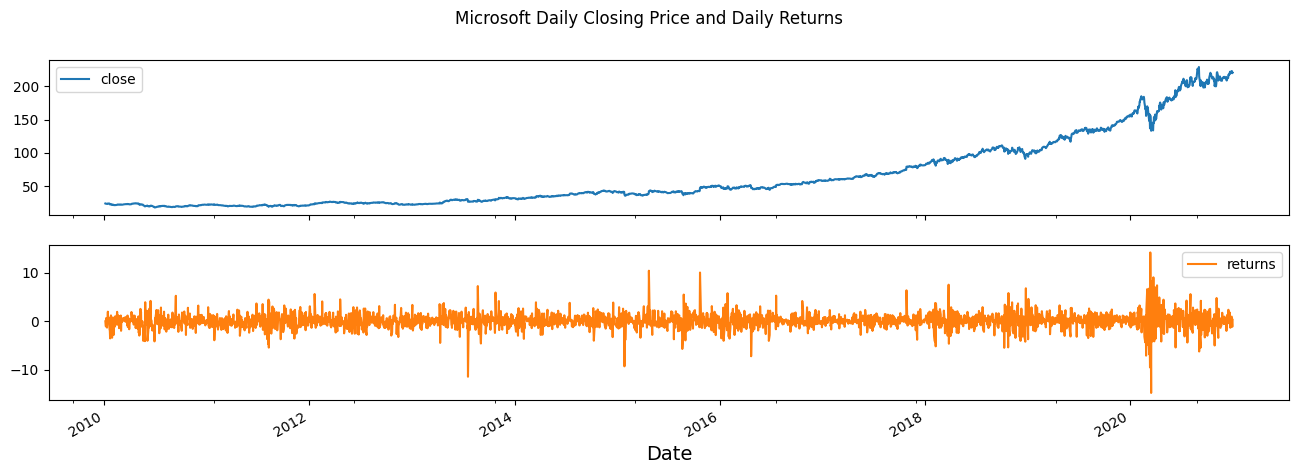

In [53]:
# Plot both the daily stock price and daily return
msft_df.plot(subplots=True, title='Microsoft Daily Closing Price and Daily Returns')

In [54]:
# Split the data into 90% train and 10% test sets
idx = round(len(msft_df) * 0.90)
train = msft_df.returns[:idx]
test = msft_df.returns[idx:]
print(f'Train: {train.shape}')
print(f'Test: {test.shape}')

Train: (2491,)
Test: (277,)


Fit the GARCH(p, q) model. Start with the simple GARCH(1,1) model with all the default options – that is, mean='Constant', distribution as dist='normal', volatility as vol='GARCH', p=1, and q=1:

In [55]:
model = arch_model(train, p=1, q=1, mean='Constant', vol='GARCH', dist='normal')

results = model.fit(update_freq=5)

Iteration:      5,   Func. Count:     36,   Neg. LLF: 4374.845453710037
Iteration:     10,   Func. Count:     62,   Neg. LLF: 4361.891627557763
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4361.891627557763
            Iterations: 11
            Function evaluations: 66
            Gradient evaluations: 11


Using update_freq=5 affects the output's frequency. The default is 1, which updates on every iteration.

In [56]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4361.89
Distribution:                  Normal   AIC:                           8731.78
Method:            Maximum Likelihood   BIC:                           8755.07
                                        No. Observations:                 2491
Date:                Thu, Jan 23 2025   Df Residuals:                     2490
Time:                        16:56:03   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1156  2.702e-02      4.279  1.877e-05 [6.266e-02,  0.169]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.3594      0.127      2.836  4.574e-03   [  0.111,  0.608]
alpha[1]       0.1458  4.424e-02      3.294  9.861e-04 [5.904e-02,  0.232]
beta[1]        0.6912  8.177e-02      8.454  2.821e-17   [  0.531,  0.852]
==========================================================================

Covariance estimator: robust
"""

The omega, alpha, and beta parameters (the 𝜔𝜔, 𝛼𝛼, and 𝛽𝛽 symbols) of the GARCH model are estimated using the maximum likelihood method. Notice that the p-value for the coefficients indicates they are significant.
You can access several of the components that you can see in the summary table by calling the appropriate attribute from the results object – for example, results.pvalues, results.tvalues, results.std_err, or results.params.

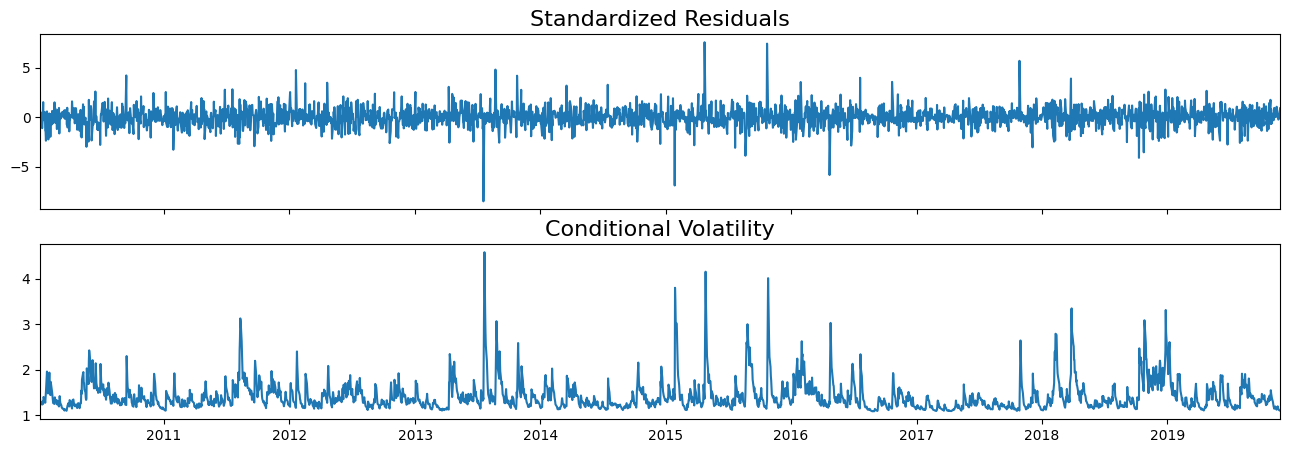

In [57]:
results.plot(); plt.show()

Text(0.5, 1.0, 'Standardized Residuals')

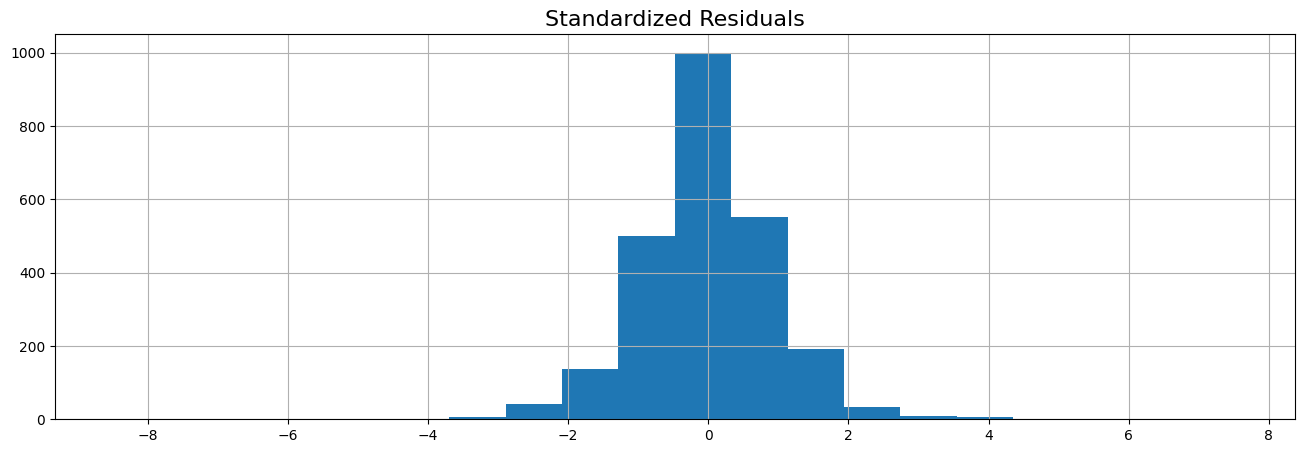

In [58]:
# Plot a histogram for the standardized residuals. You can obtain this using the std_resid attribute
results.std_resid.hist(bins=20)
plt.title('Standardized Residuals')

The histogram shows the standardized residuals being normal. Another test you can perform to check for the existence of autocorrelation is the Ljung-Box test

In [62]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(results.std_resid, lags=10, return_df=True)['lb_pvalue']

1     0.396521
2     0.530357
3     0.735656
4     0.473760
5     0.087968
6     0.070935
7     0.109796
8     0.017272
9     0.025041
10    0.021833
Name: lb_pvalue, dtype: float64

The null hypothesis assumes no autocorrelation. We reject the null hypothesis if the p-value is less than 0.05. At lags 1 to 7, we cannot reject the null hypothesis and there is no autocorrelation. Things change starting from lag 8 onward and we can reject the null hypothesis.

To make a prediction, use the .forecast() method. The default is to produce a 1 step ahead forecast. To get n number of steps ahead, you will need to update the horizon parameter

In [64]:
msft_forecast = results.forecast(horizon=test.shape[0])
msft_forecast

To access the predicted future variance (or volatility), use the .variance property from the msft_forecast object.

In [65]:
forecast = msft_forecast.variance[-1:]

You can also evaluate the predicted mean. Recall that when you fit the model, you indicated that the mean is Constant. This is further validated if you examine the mean.

In [66]:
msft_forecast.mean[-1:]

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.268,h.269,h.270,h.271,h.272,h.273,h.274,h.275,h.276,h.277
Date,,,,,,,,,,,,,,,,,,,,,
2019-11-25,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615,...,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615,0.115615


This will show a constant value of 0.115615 across all horizons.

-------

when implementing the GARCH model, the mean was set to Constant. Let's explore the impact of changing it to Zero.

In [67]:
model = arch_model(train, p=1, q=1, mean='Zero', vol='GARCH', dist='normal')

results = model.fit(disp=False)

In [68]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                       Zero Mean - GARCH Model Results                        
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4371.30
Distribution:                  Normal   AIC:                           8748.59
Method:            Maximum Likelihood   BIC:                           8766.06
                                        No. Observations:                 2491
Date:                Thu, Jan 23 2025   Df Residuals:                     2491
Time:                        17:13:35   Df Model:                            0
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.3455      0.127      2.717  6.594e-03 [9.624e-02,  0.595]
alpha[1]       0.1306  3.998e-02      3.266  1.091e-03 [5.220e-02,  0.209]
beta[1]        0.7113  8.038e-02      8.850  8.787e-19   [  0.554,  0.869]
==========================================================================

Covariance estimator: robust
"""